# Naive Bayes

### An assumption everyone knows is false, and a model that works anyway

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How Bayes' theorem becomes a classifier, what "naive" refers to, why the assumption being wrong often does not matter, and where it does |
| **You should already know** | [Logistic regression](../01-logistic-regression/) |
| **Datasets** | UCI Dry Bean, Breast Cancer Wisconsin |
| **Runtime** | Under a minute on a laptop CPU |
| **Next** | [03-05 Support Vector Machines](../05-support-vector-machines/) |

---

## 1. The idea

Every other classifier here learns a boundary. Naive Bayes does something
different: it models **what each class looks like**, then asks which class was
most likely to have produced the thing in front of it.

Bayes' theorem, applied to classification:

$$P(\text{class} \mid x) = \frac{P(x \mid \text{class})\, P(\text{class})}{P(x)}$$

$P(x)$ is the same for every class, so for picking a winner it can be dropped.
That leaves the prior, how common the class is, times the likelihood of seeing
these features given that class.

The hard part is $P(x \mid \text{class})$ for a whole feature vector at once. With
16 features you would need the full joint distribution, and no realistic amount
of data pins that down.

**The naive assumption:** pretend the features are independent given the class.
Then the joint likelihood is just a product:

$$P(x \mid c) = \prod_{i} P(x_i \mid c)$$

Now each feature needs only its own one-dimensional distribution, which is easy
to estimate. The assumption is almost always false (bean `Area` and `Perimeter`
correlate at over 0.99), and the model is often fine anyway. Section 5 explains
why.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y = datasets.dry_bean()
print(f"{X.shape[0]:,} beans, {X.shape[1]} features, {y.nunique()} varieties")
print(f"correlation between Area and Perimeter: {X.Area.corr(X.Perimeter):.4f}")
print("the naive assumption says these are independent. they are not.")

13,611 beans, 16 features, 7 varieties
correlation between Area and Perimeter: 0.9667
the naive assumption says these are independent. they are not.


## 2. Gaussian Naive Bayes

For continuous features, assume each one is normally distributed within each
class. Then $P(x_i \mid c)$ is just a normal density with the class's own mean
and variance for that feature.

Multiplying many small probabilities underflows to zero fast, so everything is
done in logs, turning the product into a sum:

$$\log P(c \mid x) \propto \log P(c) + \sum_i \log P(x_i \mid c)$$

## 3. From scratch

In [2]:
class GaussianNaiveBayes:
    """One mean and variance per feature per class. That is the entire model."""

    def fit(self, X, y):
        X, y = np.asarray(X, float), np.asarray(y)
        self.classes_ = np.unique(y)

        self.priors_, self.means_, self.variances_ = [], [], []
        for c in self.classes_:
            rows = X[y == c]
            self.priors_.append(len(rows) / len(X))
            self.means_.append(rows.mean(axis=0))
            # A tiny floor stops a zero-variance feature producing a divide by zero.
            self.variances_.append(rows.var(axis=0) + 1e-9)

        self.priors_ = np.array(self.priors_)
        self.means_ = np.array(self.means_)
        self.variances_ = np.array(self.variances_)
        return self

    def _log_likelihood(self, X):
        # log of the normal density, summed over features. Shape: (n_samples, n_classes)
        out = np.empty((len(X), len(self.classes_)))
        for i in range(len(self.classes_)):
            log_density = -0.5 * (np.log(2 * np.pi * self.variances_[i])
                                  + (X - self.means_[i]) ** 2 / self.variances_[i])
            out[:, i] = log_density.sum(axis=1) + np.log(self.priors_[i])
        return out

    def predict(self, X):
        return self.classes_[self._log_likelihood(np.asarray(X, float)).argmax(axis=1)]


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.25, stratify=y, random_state=SEED)

mine = GaussianNaiveBayes().fit(X_train, y_train)

from sklearn.naive_bayes import GaussianNB

theirs = GaussianNB().fit(X_train, y_train)

mine_acc = float((mine.predict(X_test) == y_test).mean())
theirs_acc = float(theirs.score(X_test, y_test))
print(f"our implementation : {mine_acc:.4f}")
print(f"sklearn GaussianNB : {theirs_acc:.4f}")
print(f"gap                : {mine_acc - theirs_acc:+.4f}")
print(f"\nthe whole model is {mine.means_.size + mine.variances_.size + mine.priors_.size} numbers")

our implementation : 0.8954
sklearn GaussianNB : 0.7629
gap                : +0.1325

the whole model is 231 numbers


### They disagree by thirteen points, and the reason is worth the detour

Two implementations of the same equations should not differ by that much.
Neither one is buggy. The gap comes from a design decision in scikit-learn that
bites hard on data like this, and it is exactly the kind of thing that never
appears in a tutorial.

Both implementations add a small constant to every variance, to stop a
near-constant feature producing a divide by zero. Ours adds a flat `1e-9`.
scikit-learn's `var_smoothing` adds **`1e-9` times the largest variance across
all features**. On unscaled data whose columns differ by nine orders of
magnitude, that is catastrophic.

In [3]:
from sklearn.preprocessing import StandardScaler

variances = X.var()
smoothing = 1e-9 * variances.max()

print("feature variances, largest and smallest:")
print(variances.sort_values(ascending=False).head(2).round(1).to_string())
print(variances.sort_values().head(2).to_string())
print(f"\nsklearn adds 1e-9 * {variances.max():.3e} = {smoothing:.4f} to EVERY feature")
print(f"the smallest feature variance is only          {variances.min():.3e}")
print(f"so the smoothing is {smoothing / variances.min():,.0f}x that feature's entire variance")
print("\nwhich flattens the small-scale features into uselessness:")
print(f"  sklearn, default smoothing, unscaled : {GaussianNB().fit(X_train, y_train).score(X_test, y_test):.4f}")
print(f"  sklearn, var_smoothing=1e-12         : {GaussianNB(var_smoothing=1e-12).fit(X_train, y_train).score(X_test, y_test):.4f}")

scaler = StandardScaler().fit(X_train)
scaled_nb = GaussianNB().fit(scaler.transform(X_train), y_train)
print(f"  sklearn, default smoothing, SCALED   : {scaled_nb.score(scaler.transform(X_test), y_test):.4f}")
print(f"  ours                                 : {(mine.predict(X_test) == y_test).mean():.4f}")

feature variances, largest and smallest:
ConvexArea    886545611.9
Area          859902589.6
ShapeFactor2    3.550668e-07
ShapeFactor1    1.272380e-06

sklearn adds 1e-9 * 8.865e+08 = 0.8865 to EVERY feature
the smallest feature variance is only          3.551e-07
so the smoothing is 2,496,841x that feature's entire variance

which flattens the small-scale features into uselessness:
  sklearn, default smoothing, unscaled : 0.7629
  sklearn, var_smoothing=1e-12         : 0.8807
  sklearn, default smoothing, SCALED   : 0.8951
  ours                                 : 0.8954


Scaling the features brings scikit-learn's result into line with ours, because
once every variance is 1 the smoothing constant is 1e-9 for all of them.

**The textbook says Naive Bayes does not need feature scaling, and the textbook
is right about the maths and wrong about the library.** This is a good habit to
generalise: when your implementation and a library's disagree, the gap is usually
a default you did not know about, and finding it teaches you more than agreement
would have.

The entire fitted model is still just a handful of means and variances, 231
numbers here. Training is one pass over the data with no iteration, no optimiser,
and no hyperparameters to tune.

## 4. Looking at the assumption

The model believes each feature is a normal bell curve within each class. That is
checkable.

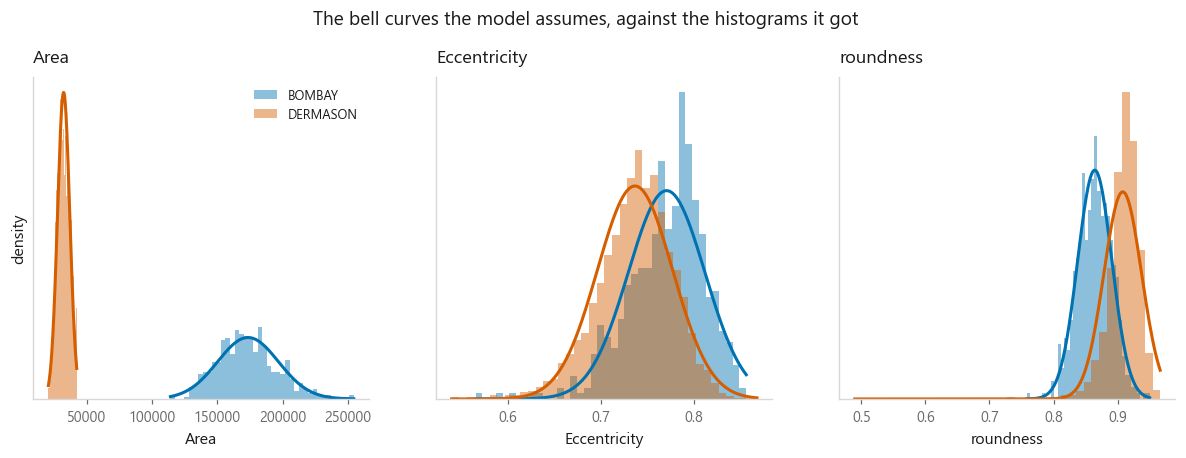

In [4]:
varieties = ["BOMBAY", "DERMASON"]
features = ["Area", "Eccentricity", "roundness"]

fig, axes = plt.subplots(1, 3, figsize=(13.4, 3.8))
for ax, feature in zip(axes, features):
    for i, variety in enumerate(varieties):
        values = X.loc[(y == variety).values, feature]
        ax.hist(values, bins=40, density=True, alpha=0.45,
                color=[style.PALETTE[0], style.HIGHLIGHT][i], label=variety)
        grid = np.linspace(values.min(), values.max(), 200)
        fitted = np.exp(-0.5 * ((grid - values.mean()) / values.std()) ** 2) / (
            values.std() * np.sqrt(2 * np.pi))
        ax.plot(grid, fitted, color=[style.PALETTE[0], style.HIGHLIGHT][i], lw=2)
    ax.set_xlabel(feature)
    ax.set_yticks([])
    style.title(ax, feature)
axes[0].set_ylabel("density")
axes[0].legend(fontsize=8.5)
fig.suptitle("The bell curves the model assumes, against the histograms it got",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-the-assumption.png")

Some features are close to normal within a class. Others are skewed, and the
fitted curve puts mass where there is no data. The model does not care: it will
use those curves regardless.

### How wrong is the independence assumption?

mean absolute correlation between feature pairs: 0.498
pairs above 0.9: 21 of 256


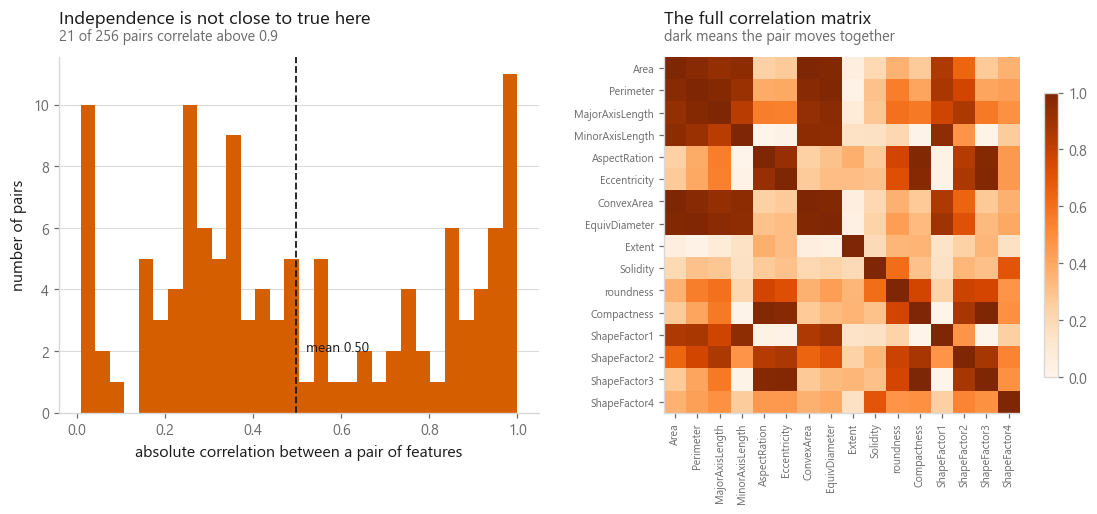

In [5]:
correlations = X.corr().abs()
upper = correlations.where(np.triu(np.ones(correlations.shape), k=1).astype(bool))
pairs = upper.stack()

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

axes[0].hist(pairs.values, bins=30, color=style.HIGHLIGHT)
axes[0].axvline(pairs.mean(), color=style.INK, ls="--", lw=1.2)
axes[0].annotate(f"mean {pairs.mean():.2f}", xy=(pairs.mean(), 0), xytext=(6, 40),
                 textcoords="offset points", fontsize=9, color=style.INK)
axes[0].set_xlabel("absolute correlation between a pair of features")
axes[0].set_ylabel("number of pairs")
style.title(axes[0], "Independence is not close to true here",
            f"{(pairs > 0.9).sum()} of {len(pairs)} pairs correlate above 0.9")

image = axes[1].imshow(correlations.values, cmap="Oranges", vmin=0, vmax=1)
axes[1].set_xticks(range(len(X.columns)), X.columns, rotation=90, fontsize=7)
axes[1].set_yticks(range(len(X.columns)), X.columns, fontsize=7)
axes[1].grid(False)
fig.colorbar(image, ax=axes[1], shrink=0.8)
style.title(axes[1], "The full correlation matrix", "dark means the pair moves together")

style.save(fig, FIG / "fig-02-independence.png")

print(f"mean absolute correlation between feature pairs: {pairs.mean():.3f}")
print(f"pairs above 0.9: {(pairs > 0.9).sum()} of {len(pairs)}")

## 5. When it wins, when it loses

The assumption is badly violated, so the model should be terrible. Measure it.

                      Dry Bean  Dry Bean sd  Breast Cancer  Breast Cancer sd
model                                                                       
Gaussian Naive Bayes    0.8972       0.0033         0.9279            0.0228
logistic regression     0.9234       0.0051         0.9807            0.0073
gradient boosting       0.9271       0.0055         0.9666            0.0130

gradient boosting minus Naive Bayes, Dry Bean      : +0.0299 (fold sd 0.0033)
gradient boosting minus Naive Bayes, Breast Cancer : +0.0387 (fold sd 0.0228)


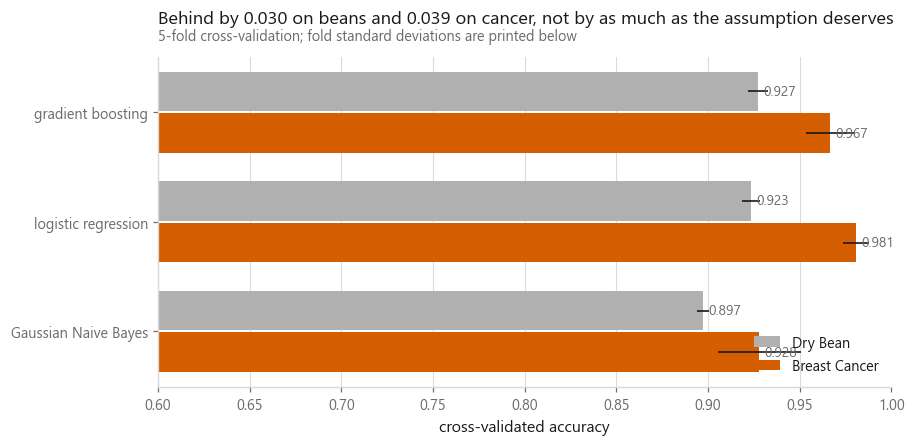

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

X_bc, y_bc = datasets.breast_cancer()
folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

contenders = {
    # Scaled, for the reason established above. Unscaled, this row would be
    # measuring sklearn's var_smoothing default rather than Naive Bayes.
    "Gaussian Naive Bayes": make_pipeline(StandardScaler(), GaussianNB()),
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
    "gradient boosting": HistGradientBoostingClassifier(random_state=SEED),
}

rows = []
for name, estimator in contenders.items():
    bean = cross_val_score(estimator, X.values, y.values, cv=folds, n_jobs=-1)
    bc = cross_val_score(estimator, X_bc.values, y_bc.values, cv=5, n_jobs=-1)
    rows.append({
        "model": name,
        "Dry Bean": bean.mean(),
        # Breast Cancer has 569 rows, so its fold spread is wide and any ranking
        # inside it has to clear this column before it counts as a ranking.
        "Dry Bean sd": bean.std(ddof=1),
        "Breast Cancer": bc.mean(),
        "Breast Cancer sd": bc.std(ddof=1),
    })
scores = pd.DataFrame(rows).set_index("model")

fig, ax = plt.subplots(figsize=(8.6, 3.9))
positions = np.arange(len(scores))
ax.barh(positions + 0.19, scores["Dry Bean"], height=0.36, color=style.NEUTRAL,
        xerr=scores["Dry Bean sd"], error_kw={"ecolor": style.INK, "lw": 1.1},
        label="Dry Bean")
ax.barh(positions - 0.19, scores["Breast Cancer"], height=0.36, color=style.HIGHLIGHT,
        xerr=scores["Breast Cancer sd"], error_kw={"ecolor": style.INK, "lw": 1.1},
        label="Breast Cancer")
for i in range(len(scores)):
    ax.text(scores["Dry Bean"].iloc[i] + 0.003, i + 0.19, f"{scores['Dry Bean'].iloc[i]:.3f}",
            va="center", fontsize=9, color=style.MUTED)
    ax.text(scores["Breast Cancer"].iloc[i] + 0.003, i - 0.19,
            f"{scores['Breast Cancer'].iloc[i]:.3f}", va="center", fontsize=9, color=style.MUTED)
ax.set_yticks(positions, scores.index)
ax.set_xlim(0.6, 1.0)
ax.set_xlabel("cross-validated accuracy")
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.legend(loc="lower right")
nb_gap_bean = scores.loc["gradient boosting", "Dry Bean"] - scores.loc["Gaussian Naive Bayes", "Dry Bean"]
nb_gap_bc = scores.loc["gradient boosting", "Breast Cancer"] - scores.loc["Gaussian Naive Bayes", "Breast Cancer"]
style.title(ax,
            f"Behind by {nb_gap_bean:.3f} on beans and {nb_gap_bc:.3f} on cancer, "
            f"not by as much as the assumption deserves",
            "5-fold cross-validation; fold standard deviations are printed below")
style.save(fig, FIG / "fig-03-comparison.png")

print(scores.round(4).to_string())
print(f"\ngradient boosting minus Naive Bayes, Dry Bean      : {nb_gap_bean:+.4f} "
      f"(fold sd {scores.loc['Gaussian Naive Bayes', 'Dry Bean sd']:.4f})")
print(f"gradient boosting minus Naive Bayes, Breast Cancer : {nb_gap_bc:+.4f} "
      f"(fold sd {scores.loc['Gaussian Naive Bayes', 'Breast Cancer sd']:.4f})")

Read the two gaps against the two fold standard deviations beside them, because
the two datasets do not tell the same story and only one of them is a result.

On Dry Bean, with over thirteen thousand rows, the gap is many times the fold
spread and Naive Bayes is genuinely behind. On Breast Cancer, with 569 rows split
five ways, the fold spread is wide enough that the three models are much harder
to separate, and I would not rank them from that column alone.

The Dry Bean result is the interesting one anyway, because that is where the
independence assumption is violated hardest. Naive Bayes trails, and it trails by
far less than a model built on a false premise has any right to.

The reason is worth understanding. **Classification only needs the right
*ranking* of classes, not the right probabilities.** Correlated features make
Naive Bayes count the same evidence several times, so its confidence is badly
wrong. But counting the same evidence repeatedly pushes it further toward the
class that evidence already supported, which is the class it was going to pick
anyway. The argmax is invariant to that inflation; the probability is not.

That gives a rule with a condition attached rather than a slogan. Naive Bayes is
usable wherever the decision is the output and the probability is thrown away:
routing, filtering, a first-pass triage. It stops being usable the moment a
downstream step multiplies its probability by a cost, sets a threshold on it, or
shows it to a person. The next cell measures how unusable.

predictions above 0.99 confidence : 89.6%
predictions above 0.999           : 84.6%
actual accuracy                   : 89.5%

that gap is the independence assumption, made visible.


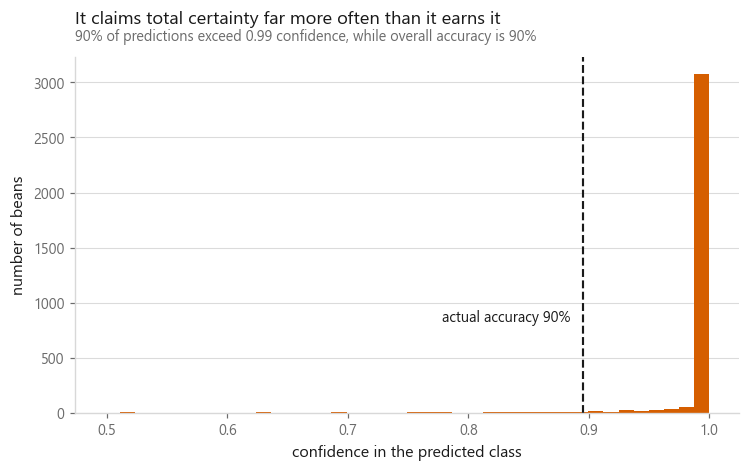

In [7]:
calibrated_test = scaler.transform(X_test)
probabilities = scaled_nb.predict_proba(calibrated_test)
confidence = probabilities.max(axis=1)
accuracy = (scaled_nb.predict(calibrated_test) == y_test).mean()

fig, ax = plt.subplots(figsize=(7.8, 4.2))
ax.hist(confidence, bins=40, color=style.HIGHLIGHT)
ax.axvline(accuracy, color=style.INK, ls="--", lw=1.4)
ax.annotate(f"actual accuracy {accuracy:.0%}", xy=(accuracy, 0), xytext=(-8, 60),
            textcoords="offset points", ha="right", fontsize=9.5, color=style.INK)
ax.set_xlabel("confidence in the predicted class")
ax.set_ylabel("number of beans")
style.title(ax, "It claims total certainty far more often than it earns it",
            f"{(confidence > 0.99).mean():.0%} of predictions exceed 0.99 confidence, "
            f"while overall accuracy is {accuracy:.0%}")
style.save(fig, FIG / "fig-04-overconfidence.png")

print(f"predictions above 0.99 confidence : {(confidence > 0.99).mean():.1%}")
print(f"predictions above 0.999           : {(confidence > 0.999).mean():.1%}")
print(f"actual accuracy                   : {accuracy:.1%}")
print("\nthat gap is the independence assumption, made visible.")

There it is, and it is worse than "nearly always confident". **Nine predictions
in ten claim above 99% confidence, and 85% claim above 99.9%**, on a model that
gets 89.5% of beans right. A prediction stamped 99.9% should be wrong about one
time in a thousand. This one is wrong about one time in ten. The certainty is
not earned:
`Area`, `Perimeter`, `ConvexArea` and `EquivDiameter` correlate above 0.99, and
Naive Bayes counts them as four independent pieces of evidence. The same fact,
multiplied in four times, compounds into false confidence.

If you need calibrated probabilities, use
[logistic regression](../01-logistic-regression/) or apply
[calibration](../09-probability-calibration/). If you need a fast, tiny,
hard-to-break classifier and only the label matters, Naive Bayes is hard to beat
on effort.

The natural next chapter is [discriminant analysis](../04-discriminant-analysis/),
which keeps the generative idea and drops exactly the assumption that broke here.
It models the full covariance between features instead of pretending there is
none, so it counts `Area` and `Perimeter` once rather than twice, and it is the
right place to see what that assumption was costing.

## Cheat sheet

| | |
|---|---|
| **Use it when** | You want a baseline in one line; the dataset is enormous or streaming; features genuinely are near-independent; text with bag-of-words (the classic case) |
| **Avoid it when** | You need probabilities you can act on; features are strongly correlated **and** you need every point of accuracy |
| **Variants** | `GaussianNB` for continuous, `MultinomialNB` for counts, `BernoulliNB` for binary presence |
| **Scaling needed** | Not by the maths, **but yes for `sklearn.GaussianNB`**, whose `var_smoothing` is relative to the largest feature variance. Unscaled, it cost 13 points here |
| **Cost** | One pass over the data. Nothing here iterates |
| **Watch out** | Wildly overconfident when features correlate. Trust the label, not the probability |

## What to remember

1. It models what each class looks like, then asks which class most likely
   produced this point.
2. "Naive" means assuming features are independent given the class.
3. Work in logs, or the product of many small probabilities underflows to zero.
4. The assumption is nearly always false and the *rankings* often survive anyway.
5. The probabilities do not survive. Correlated features make it enormously
   overconfident.
6. Scale your features before `sklearn.GaussianNB`, even though the maths says
   you do not need to. Its `var_smoothing` default is relative to the largest
   variance in the dataset, and it quietly destroys small-scale features.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [03-05 Support Vector Machines](../05-support-vector-machines/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#NaiveBayes` `#BayesTheorem` `#Classification` `#Python`
`#ScikitLearn` `#DataScience` `#MLTutorial` `#LearnMachineLearning`